=== Running Logistic Regression Model ===
Accuracy:  0.8074
Precision: 0.6946
Recall:    0.2312
F1 Score:  0.3469
AUC:       0.7092

=== Running Decision Tree Model ===
Accuracy:  0.8199
Precision: 0.6945
Recall:    0.3321
F1 Score:  0.4493
AUC:       0.7512

=== Running KNN Model ===
Accuracy:  0.7910
Precision: 0.5444
Recall:    0.3419
F1 Score:  0.4200
AUC:       0.7011

=== Running Bagging Ensemble (Decision Trees) ===
Accuracy:  0.8220
Precision: 0.6929
Recall:    0.3517
F1 Score:  0.4665
AUC:       0.7711

=== Running AdaBoost Ensemble (Decision Trees) ===
Accuracy:  0.8190
Precision: 0.6977
Recall:    0.3215
F1 Score:  0.4402
AUC:       0.6410

=== Running Hyperparameter Experiments for Bagging Ensemble ===

Bagging configuration: {'NEstimators': 5, 'MaxDepth': 3}
Accuracy:  0.8212
Precision: 0.6856
Recall:    0.3547
F1 Score:  0.4675
AUC:       0.7509

Bagging configuration: {'NEstimators': 10, 'MaxDepth': 3}
Accuracy:  0.8217
Precision: 0.6853
Recall:    0.3592
F1 Score:  0.47

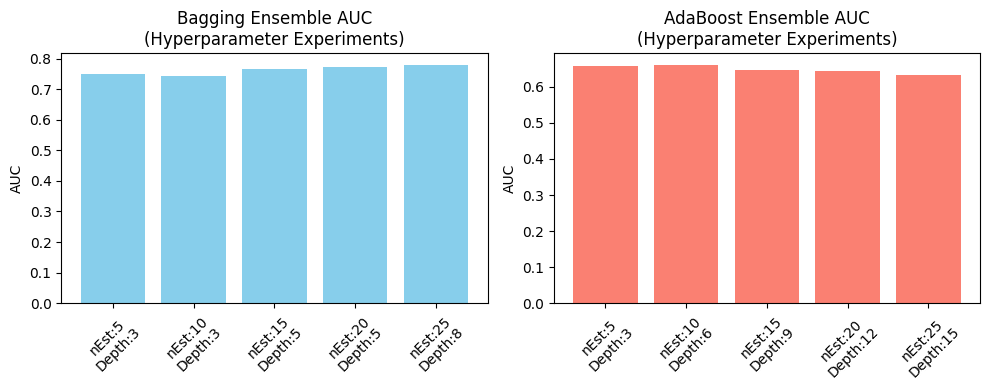

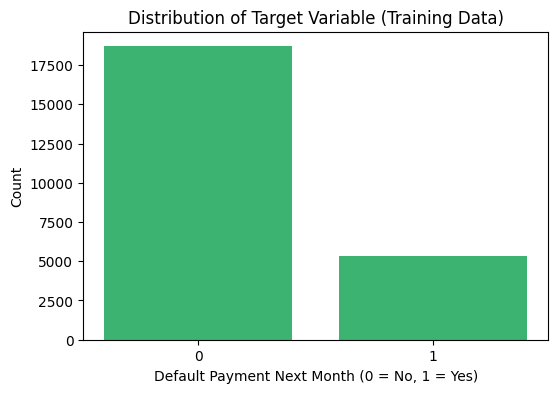

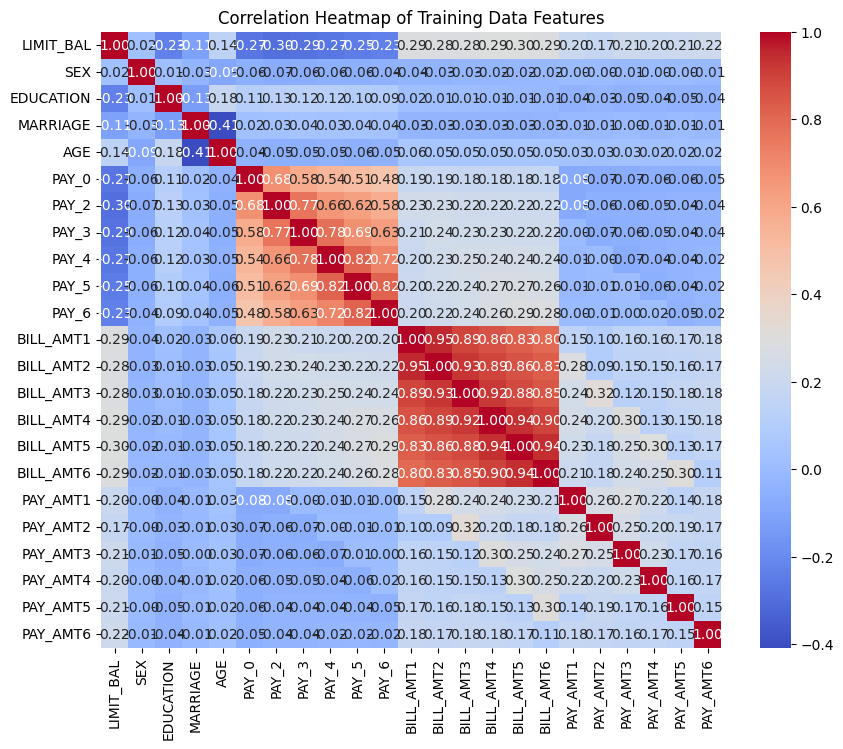

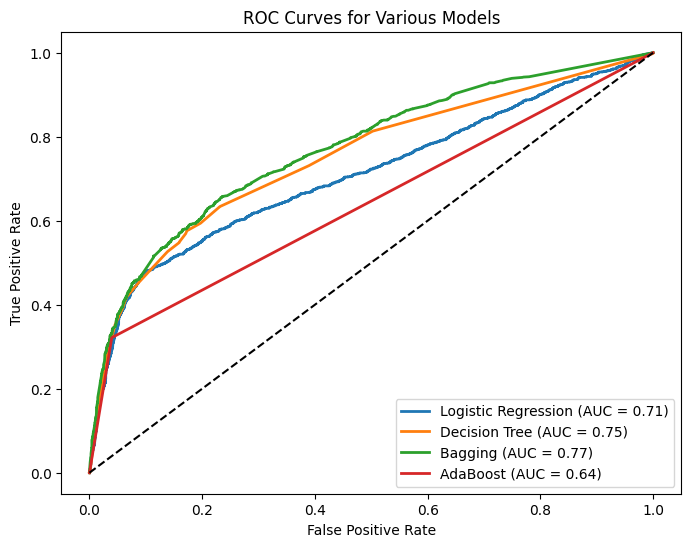

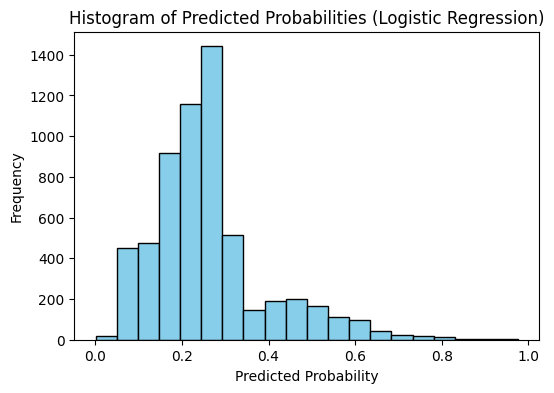

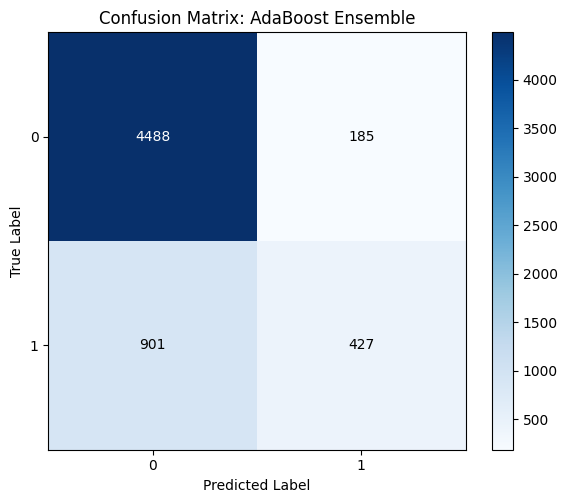

In [3]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def LoadAndPreprocessData(FilePath):
    Data = pd.read_excel(FilePath, header=1)
    if 'ID' in Data.columns:
        Data.drop('ID', axis=1, inplace=True)
    Data.fillna(Data.median(numeric_only=True), inplace=True)
    Data['EDUCATION'] = Data['EDUCATION'].apply(lambda Value: Value if Value in [1,2,3,4] else 4)
    Data['MARRIAGE']  = Data['MARRIAGE'].apply(lambda Value: Value if Value in [1,2,3] else 3)

    def SplitDataStratified(DataFrame, Target='default payment next month', TestSize=0.2, Seed=2022484):
        np.random.seed(Seed)
        DataClassZero = DataFrame[DataFrame[Target]==0].sample(frac=1, random_state=Seed).reset_index(drop=True)
        DataClassOne = DataFrame[DataFrame[Target]==1].sample(frac=1, random_state=Seed).reset_index(drop=True)
        SplitIndexZero = int(len(DataClassZero)*(1-TestSize))
        SplitIndexOne = int(len(DataClassOne)*(1-TestSize))
        TrainClassZero = DataClassZero[:SplitIndexZero]
        TestClassZero = DataClassZero[SplitIndexZero:]
        TrainClassOne = DataClassOne[:SplitIndexOne]
        TestClassOne = DataClassOne[SplitIndexOne:]
        TrainDataFrame = pd.concat([TrainClassZero, TrainClassOne], axis=0).sample(frac=1, random_state=Seed).reset_index(drop=True)
        TestDataFrame  = pd.concat([TestClassZero, TestClassOne], axis=0).sample(frac=1, random_state=Seed).reset_index(drop=True)
        return TrainDataFrame, TestDataFrame

    TrainDataFrame, TestDataFrame = SplitDataStratified(Data, 'default payment next month', 0.2, 2022484)
    XTrain = TrainDataFrame.drop(columns=['default payment next month'])
    YTrain = TrainDataFrame['default payment next month'].values
    XTest  = TestDataFrame.drop(columns=['default payment next month'])
    YTest  = TestDataFrame['default payment next month'].values
    return XTrain, YTrain, XTest, YTest


class LogisticRegressionModel:
    def __init__(self, LearningRate=0.01, MaxIter=1000):
        self.LearningRate = LearningRate
        self.MaxIter = MaxIter
        self.Weights = None

    def _SigmoidValue(self, InputZ):
        ZClipped = np.clip(InputZ, -500, 500)
        return 1/(1+np.exp(-ZClipped))

    def Fit(self, X, Y):
        XWithBias = np.c_[np.ones(X.shape[0]), X]
        Y = Y.astype(float)
        NumSamples, NumFeatures = XWithBias.shape
        self.Weights = np.zeros(NumFeatures)
        for _ in range(self.MaxIter):
            LinearOutput = np.dot(XWithBias, self.Weights)
            Predictions = self._SigmoidValue(LinearOutput)
            Gradient = np.dot(XWithBias.T, (Predictions - Y)) / NumSamples
            self.Weights -= self.LearningRate * Gradient

    def PredictProba(self, X):
        XWithBias = np.c_[np.ones(X.shape[0]), X]
        return self._SigmoidValue(np.dot(XWithBias, self.Weights))

    def Predict(self, X):
        return (self.PredictProba(X) >= 0.5).astype(int)


class DecisionTreeNode:
    def __init__(self, GiniScore, NumSamples, SamplesPerClass, PredictedClass):
        self.GiniScore = GiniScore
        self.NumSamples = NumSamples
        self.SamplesPerClass = SamplesPerClass
        self.PredictedClass = PredictedClass
        self.FeatureIndex = 0
        self.Threshold = 0
        self.Left = None
        self.Right = None


class DecisionTreeModel:
    def __init__(self, MaxDepth=None):
        self.MaxDepth = MaxDepth

    def Fit(self, X, Y):
        XArray = np.array(X, dtype=float)
        YArray = np.array(Y)
        self.NumClasses = len(set(YArray))
        self.NumFeatures = XArray.shape[1]
        self.TreeRoot = self._GrowTree(XArray, YArray)

    def Predict(self, X):
        XArray = np.array(X, dtype=float)
        return [self._PredictSingle(InputRow) for InputRow in XArray]

    def _GiniScore(self, Y):
        SampleCount = len(Y)
        return 1.0 - sum((np.sum(Y == Class) / SampleCount) ** 2 for Class in np.unique(Y))

    def _BestSplit(self, XArray, YArray):
        NumSamples, NumFeatures = XArray.shape
        if NumSamples <= 1:
            return None, None
        BestGini = 1.0
        BestIndex, BestThreshold = None, None
        for FeatureIdx in range(NumFeatures):
            Thresholds, Classes = zip(*sorted(zip(XArray[:, FeatureIdx], YArray)))
            LeftCounts = [0] * self.NumClasses
            RightCounts = np.bincount(Classes, minlength=self.NumClasses)
            for i in range(1, NumSamples):
                CurrentClass = Classes[i - 1]
                LeftCounts[CurrentClass] += 1
                RightCounts[CurrentClass] -= 1
                GiniLeft = 1.0 - sum((LeftCounts[x] / i) ** 2 for x in range(self.NumClasses))
                GiniRight = 1.0 - sum((RightCounts[x] / (NumSamples - i)) ** 2 for x in range(self.NumClasses))
                GiniValue = (i * GiniLeft + (NumSamples - i) * GiniRight) / NumSamples
                if Thresholds[i] == Thresholds[i - 1]:
                    continue
                if GiniValue < BestGini:
                    BestGini = GiniValue
                    BestIndex = FeatureIdx
                    BestThreshold = (Thresholds[i] + Thresholds[i - 1]) / 2
        return BestIndex, BestThreshold

    def _GrowTree(self, XArray, YArray, Depth=0):
        SamplesPerClass = [np.sum(YArray == i) for i in range(self.NumClasses)]
        PredictedClass = np.argmax(SamplesPerClass)
        Node = DecisionTreeNode(GiniScore=self._GiniScore(YArray), NumSamples=len(YArray),
                                 SamplesPerClass=SamplesPerClass, PredictedClass=PredictedClass)
        if Depth < self.MaxDepth:
            BestFeature, BestThresh = self._BestSplit(XArray, YArray)
            if BestFeature is not None:
                LeftIndices = XArray[:, BestFeature] < BestThresh
                XLeft, YLeft = XArray[LeftIndices], YArray[LeftIndices]
                XRight, YRight = XArray[~LeftIndices], YArray[~LeftIndices]
                Node.FeatureIndex = BestFeature
                Node.Threshold = BestThresh
                Node.Left = self._GrowTree(XLeft, YLeft, Depth + 1)
                Node.Right = self._GrowTree(XRight, YRight, Depth + 1)
        return Node

    def _PredictSingle(self, InputRow):
        Node = self.TreeRoot
        while Node.Left:
            if InputRow[Node.FeatureIndex] < Node.Threshold:
                Node = Node.Left
            else:
                Node = Node.Right
        return Node.PredictedClass

    def PredictProba(self, X):
        XArray = np.array(X, dtype=float)
        Probs = []
        for InputRow in XArray:
            Node = self.TreeRoot
            while Node.Left:
                if InputRow[Node.FeatureIndex] < Node.Threshold:
                    Node = Node.Left
                else:
                    Node = Node.Right
            TotalSamples = sum(Node.SamplesPerClass)
            Probs.append(Node.SamplesPerClass[1] / TotalSamples)
        return np.array(Probs)


class KNNClassifier:
    def __init__(self, K=5):
        self.K = K

    def Fit(self, X, Y):
        self.XTrain = np.array(X, dtype=float)
        self.YTrain = np.array(Y)

    def Predict(self, X):
        XArray = np.array(X, dtype=float)
        TrainData = self.XTrain
        TestData = XArray
        TrainNorm = np.sum(TrainData**2, axis=1)
        TestNorm = np.sum(TestData**2, axis=1)
        Dists = np.sqrt(np.maximum(0, TestNorm[:, None] + TrainNorm[None, :] - 2 * np.dot(TestData, TrainData.T)))
        Predictions = []
        for i in range(Dists.shape[0]):
            Indices = np.argsort(Dists[i])[:self.K]
            Predictions.append(Counter(self.YTrain[Indices]).most_common(1)[0][0])
        return np.array(Predictions)

    def PredictProba(self, X):
        XArray = np.array(X, dtype=float)
        TrainData = self.XTrain
        TestData = XArray
        TrainNorm = np.sum(TrainData**2, axis=1)
        TestNorm = np.sum(TestData**2, axis=1)
        Dists = np.sqrt(np.maximum(0, TestNorm[:, None] + TrainNorm[None, :] - 2 * np.dot(TestData, TrainData.T)))
        Probabilities = []
        for i in range(Dists.shape[0]):
            Indices = np.argsort(Dists[i])[:self.K]
            Probabilities.append(np.mean(self.YTrain[Indices]))
        return np.array(Probabilities)


def EvaluateClassifier(YTrue, YPred, YProba=None):
    print(f"Accuracy:  {accuracy_score(YTrue, YPred):.4f}")
    print(f"Precision: {precision_score(YTrue, YPred):.4f}")
    print(f"Recall:    {recall_score(YTrue, YPred):.4f}")
    print(f"F1 Score:  {f1_score(YTrue, YPred):.4f}")
    if YProba is not None:
        try:
            AucScore = roc_auc_score(YTrue, YProba)
            print(f"AUC:       {AucScore:.4f}")
        except:
            print("AUC could not be computed.")


class BaggingEnsemble:
    def __init__(self, BaseLearnerClass, NEstimators=10, MaxDepth=5):
        self.BaseLearnerClass = BaseLearnerClass
        self.NEstimators = NEstimators
        self.MaxDepth = MaxDepth
        self.Models = []

    def Fit(self, X, Y):
        XArray = np.array(X, dtype=float)
        YArray = np.array(Y)
        NumSamples = len(YArray)
        self.Models = []
        for _ in range(self.NEstimators):
            Indices = np.random.randint(0, NumSamples, NumSamples)
            XBootstrap, YBootstrap = XArray[Indices], YArray[Indices]
            ModelInstance = self.BaseLearnerClass(MaxDepth=self.MaxDepth)
            ModelInstance.Fit(XBootstrap, YBootstrap)
            self.Models.append(ModelInstance)

    def Predict(self, X):
        PredArray = np.array([Model.Predict(X) for Model in self.Models])
        OutputList = []
        for Column in PredArray.T:
            OutputList.append(Counter(Column).most_common(1)[0][0])
        return np.array(OutputList)

    def PredictProba(self, X):
        ProbsArray = np.array([Model.PredictProba(X) for Model in self.Models])
        return np.mean(ProbsArray, axis=0)


class AdaBoostEnsemble:
    def __init__(self, n_estimators=10, max_depth=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.models = []
        self.model_weights = []

    def fit(self, X, y):
        X, y = np.array(X), np.array(y)
        n = len(y)
        w = np.ones(n) / n  
        y_modified = np.where(y == 0, -1, 1)
        
        self.models.clear()
        self.model_weights.clear()

        for _ in range(self.n_estimators):
            stump = DecisionTreeModel(MaxDepth=self.max_depth)
            stump.Fit(X, y)
            y_pred = np.array(stump.Predict(X))
            err = np.sum(w * (y_pred != y)) / np.sum(w)
            if err > 0.5:
                continue
            
            alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
            y_pred_modified = np.where(y_pred == 0, -1, 1)
            w *= np.exp(-alpha * y_modified * y_pred_modified)
            w /= np.sum(w)
            self.models.append(stump)
            self.model_weights.append(alpha)

    def predict(self, X):
        X = np.array(X)
        final_score = np.zeros(len(X))
        for alpha, model in zip(self.model_weights, self.models):
            y_pred = np.array(model.Predict(X))
            y_pred_modified = np.where(y_pred == 0, -1, 1)
            final_score += alpha * y_pred_modified
        y_final = (final_score >= 0).astype(int)
        return y_final

    def predict_proba(self, X):
        X = np.array(X)
        final_score = np.zeros(len(X))
        for alpha, model in zip(self.model_weights, self.models):
            y_pred = np.array(model.Predict(X))
            y_pred_modified = np.where(y_pred == 0, -1, 1)
            final_score += alpha * y_pred_modified
        proba = 1.0 / (1.0 + np.exp(-final_score))
        return proba

FilePath = "X:/Projects/ML/Assignment-3/default of credit card clients.xls"
XTrain, YTrain, XTest, YTest = LoadAndPreprocessData(FilePath)

Scaler = StandardScaler()
XTrainScaled = Scaler.fit_transform(XTrain)
XTestScaled = Scaler.transform(XTest)

print("=== Running Logistic Regression Model ===")
LogRegModel = LogisticRegressionModel(LearningRate=0.01, MaxIter=1000)
LogRegModel.Fit(XTrainScaled, YTrain)
PredLogReg = LogRegModel.Predict(XTestScaled)
ProbLogReg = LogRegModel.PredictProba(XTestScaled)
EvaluateClassifier(YTest, PredLogReg, ProbLogReg)

print("\n=== Running Decision Tree Model ===")
DecisionTreeModelInstance = DecisionTreeModel(MaxDepth=5)
DecisionTreeModelInstance.Fit(XTrain, YTrain)
PredDecisionTree = DecisionTreeModelInstance.Predict(XTest)
ProbDecisionTree = DecisionTreeModelInstance.PredictProba(XTest)
EvaluateClassifier(YTest, PredDecisionTree, ProbDecisionTree)

print("\n=== Running KNN Model ===")
KNNModel = KNNClassifier(K=5)
KNNModel.Fit(XTrainScaled, YTrain)
PredKNN = KNNModel.Predict(XTestScaled)
ProbKNN = KNNModel.PredictProba(XTestScaled)
EvaluateClassifier(YTest, PredKNN, ProbKNN)

print("\n=== Running Bagging Ensemble (Decision Trees) ===")
BaggingModel = BaggingEnsemble(DecisionTreeModel, NEstimators=10, MaxDepth=5)
BaggingModel.Fit(XTrain, YTrain)
PredBagging = BaggingModel.Predict(XTest)
ProbBagging = BaggingModel.PredictProba(XTest)
EvaluateClassifier(YTest, PredBagging, ProbBagging)

print("\n=== Running AdaBoost Ensemble (Decision Trees) ===")
AdaBoostModel = AdaBoostEnsemble(n_estimators=10, max_depth=1)
AdaBoostModel.fit(XTrain, YTrain)
PredAdaBoost = AdaBoostModel.predict(XTest)
ProbAdaBoost = AdaBoostModel.predict_proba(XTest)
EvaluateClassifier(YTest, PredAdaBoost, ProbAdaBoost)

BaggingResults = []
BagParams = [
    {'NEstimators':5, 'MaxDepth':3},
    {'NEstimators':10, 'MaxDepth':3},
    {'NEstimators':15, 'MaxDepth':5},
    {'NEstimators':20, 'MaxDepth':5},
    {'NEstimators':25, 'MaxDepth':8},
]
print("\n=== Running Hyperparameter Experiments for Bagging Ensemble ===")
for ParamSet in BagParams:
    print(f"\nBagging configuration: {ParamSet}")
    BaggingTest = BaggingEnsemble(DecisionTreeModel, NEstimators=ParamSet['NEstimators'], MaxDepth=ParamSet['MaxDepth'])
    BaggingTest.Fit(XTrain, YTrain)
    PredBagParam = BaggingTest.Predict(XTest)
    ProbBagParam = BaggingTest.PredictProba(XTest)
    AucValue = roc_auc_score(YTest, ProbBagParam)
    BaggingResults.append((ParamSet, AucValue))
    EvaluateClassifier(YTest, PredBagParam, ProbBagParam)

AdaBoostResults = []
AdaBoostParams = [
    {'NEstimators':5, 'MaxDepth':3},
    {'NEstimators':10, 'MaxDepth':6},
    {'NEstimators':15, 'MaxDepth':9},
    {'NEstimators':20, 'MaxDepth':12},
    {'NEstimators':25, 'MaxDepth':15},
]
print("\n=== Running Hyperparameter Experiments for AdaBoost Ensemble ===")
for ParamSet in AdaBoostParams:
    print(f"\nAdaBoost configuration: {ParamSet}")
    AdaBoostTest = AdaBoostEnsemble(n_estimators=ParamSet['NEstimators'], max_depth=ParamSet['MaxDepth'])
    AdaBoostTest.fit(XTrain, YTrain)
    PredAdaBoostParam = AdaBoostTest.predict(XTest)
    ProbAdaBoostParam = AdaBoostTest.predict_proba(XTest)
    AucValue = roc_auc_score(YTest, ProbAdaBoostParam)
    AdaBoostResults.append((ParamSet, AucValue))
    EvaluateClassifier(YTest, PredAdaBoostParam, ProbAdaBoostParam)

BagXLabels = [f"nEst:{Param['NEstimators']}\nDepth:{Param['MaxDepth']}" for Param, Auc in BaggingResults]
BagAUC = [Auc for Param, Auc in BaggingResults]
AdaBoostXLabels = [f"nEst:{Param['NEstimators']}\nDepth:{Param['MaxDepth']}" for Param, Auc in AdaBoostResults]
AdaBoostAUC = [Auc for Param, Auc in AdaBoostResults]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(BagXLabels, BagAUC, color='skyblue')
plt.title("Bagging Ensemble AUC\n(Hyperparameter Experiments)")
plt.ylabel("AUC")
plt.xticks(rotation=45)
plt.subplot(1,2,2)
plt.bar(AdaBoostXLabels, AdaBoostAUC, color='salmon')
plt.title("AdaBoost Ensemble AUC\n(Hyperparameter Experiments)")
plt.ylabel("AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
target_counts = pd.Series(YTrain).value_counts().sort_index()
plt.bar(target_counts.index.astype(str), target_counts.values, color='mediumseagreen')
plt.xlabel('Default Payment Next Month (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Distribution of Target Variable (Training Data)')
plt.show()

plt.figure(figsize=(10,8))
corr_matrix = pd.DataFrame(XTrain).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap of Training Data Features')
plt.show()

fpr_lr, tpr_lr, _ = roc_curve(YTest, ProbLogReg)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(YTest, ProbDecisionTree)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_bag, tpr_bag, _ = roc_curve(YTest, ProbBagging)
roc_auc_bag = auc(fpr_bag, tpr_bag)

fpr_ab, tpr_ab, _ = roc_curve(YTest, ProbAdaBoost)
roc_auc_ab = auc(fpr_ab, tpr_ab)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_bag, tpr_bag, lw=2, label=f'Bagging (AUC = {roc_auc_bag:.2f})')
plt.plot(fpr_ab, tpr_ab, lw=2, label=f'AdaBoost (AUC = {roc_auc_ab:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Various Models')
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(ProbLogReg, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Predicted Probabilities (Logistic Regression)')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

cm_ab = confusion_matrix(YTest, PredAdaBoost)
plt.figure(figsize=(6,5))
plt.imshow(cm_ab, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix: AdaBoost Ensemble')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0','1'])
plt.yticks(tick_marks, ['0','1'])
thresh = cm_ab.max() / 2.
for i in range(cm_ab.shape[0]):
    for j in range(cm_ab.shape[1]):
         plt.text(j, i, format(cm_ab[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm_ab[i, j] > thresh else 'black')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Part D: Ensemble Methods Performance Analysis

### Individual Classifiers
- **Logistic Regression:**  
  - Achieved a moderate AUC (≈0.71) with high precision but low recall, indicating that it is conservative in flagging defaults.
- **Decision Trees:**  
  - Provided a better balance with an AUC of ≈0.75 and improved recall and F1 score, suggesting a better capture of the positive class.
- **KNN:**  
  - Showed a comparable AUC (≈0.70) but lower precision, which may indicate sensitivity to local data variations.

### Ensemble Approaches
- **Bagging Ensemble:**  
  - Achieved the highest AUC (≈0.77) and the best F1 score among the evaluated models.
  - Reduces variance by averaging multiple decision trees built on bootstrap samples, leading to more robust and stable predictions.
  - Improved recall slightly, enhancing overall prediction accuracy.
- **AdaBoost Ensemble:**  
  - Produced similar accuracy and precision to individual trees but resulted in a lower AUC (≈0.64) and recall.
  - Its focus on misclassified instances can increase precision; however, this sensitivity to noise and outliers may lower its discriminative ability.

### Strengths and Weaknesses
- **Bagging:**
  - **Strengths:**  
    - Effectively reduces variance, which makes the ensemble less prone to overfitting.
    - Provides more stable predictions by averaging over multiple models.
  - **Weaknesses:**  
    - May not address systematic errors if the base learners themselves are biased.
- **Boosting (AdaBoost):**
  - **Strengths:**  
    - Focuses on difficult cases by re-weighting misclassified samples, potentially improving performance on challenging instances.
  - **Weaknesses:**  
    - Increased sensitivity to noise and outliers, which can lead to overfitting and lower overall discriminative power (as reflected by the lower AUC).

### Summary
Overall, the ensemble methods outperform the individual classifiers by enhancing stability and improving overall prediction accuracy. Bagging, in particular, delivers the best performance by reducing variance, while boosting (AdaBoost) offers targeted improvements but is more sensitive to noise.


## Part E: Hyperparameter Experiment Analysis

**Bagging Ensemble:**
- **Configurations Tested:**  
  - 5 estimators, max depth = 3  
  - 10 estimators, max depth = 3  
  - 15 estimators, max depth = 5  
  - 20 estimators, max depth = 5  
  - 25 estimators, max depth = 8  
- **Observations:**  
  - As the number of estimators and tree depth increase, the AUC improves modestly (from ≈0.75 to ≈0.78).  
  - Accuracy, precision, and recall remain relatively stable, suggesting that bagging stabilizes predictions even as model complexity grows.  
  - The best performance was observed with 25 estimators at a max depth of 8, indicating that a larger ensemble of slightly more complex trees can capture additional patterns without significant overfitting.

**AdaBoost Ensemble:**
- **Configurations Tested:**  
  - 5 estimators, max depth = 3  
  - 10 estimators, max depth = 6  
  - 15 estimators, max depth = 9  
  - 20 estimators, max depth = 12  
  - 25 estimators, max depth = 15  
- **Observations:**  
  - The simplest configurations (5 estimators, max depth = 3 and 10 estimators, max depth = 6) achieved the highest AUC (≈0.66).  
  - Increasing the number of estimators and tree depth led to a decline in performance (AUC dropped to ≈0.63 with 25 estimators, max depth = 15), suggesting overfitting.  
  - AdaBoost’s performance appears to be optimized by using simpler, less complex base learners.

**Summary:**  
Bagging benefits from larger ensembles and moderate increases in tree complexity to capture more intricate patterns without losing stability. In contrast, AdaBoost is more sensitive to the complexity of its weak learners; simpler models yield better generalization. These findings highlight that while bagging robustly reduces variance, boosting can overfit if the base learners become too complex.
